In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw_analyst_ratings.csv')

In [3]:
# --- 1. Descriptive Statistics: Headline Length ---
df['headline_length'] = df['headline'].astype(str).apply(len)

In [4]:
# Show basic stats
print("Headline Length Stats:\n", df['headline_length'].describe())

Headline Length Stats:
 count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


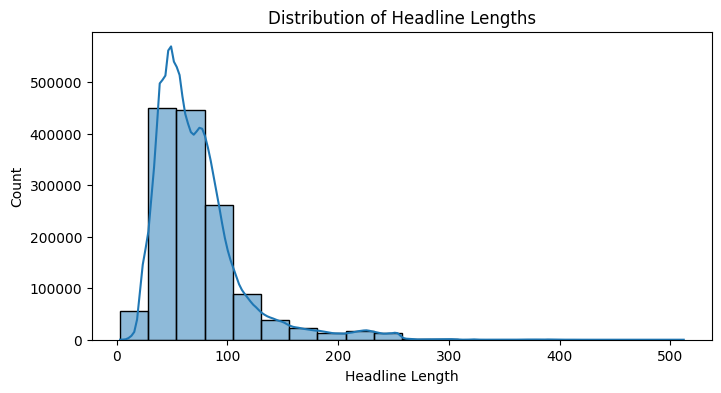

In [5]:
# Distribution plot
plt.figure(figsize=(8, 4))
sns.histplot(df['headline_length'], kde=True, bins=20)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length')
plt.ylabel('Count')
plt.show()

In [6]:
# --- 2. Articles per Publisher ---
publisher_counts = df['publisher'].value_counts()
print("\nArticles per Publisher:\n", publisher_counts)


Articles per Publisher:
 publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64


In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # coerce will handle badly formatted dates as NaT

df['date'] = df['date'].dt.tz_convert('UTC') if df['date'].dt.tz is not None else df['date']

# Extract just the date (drop time)
df['pub_date'] = df['date'].dt.date

# Count articles per day
daily_counts = df.groupby('pub_date').size()

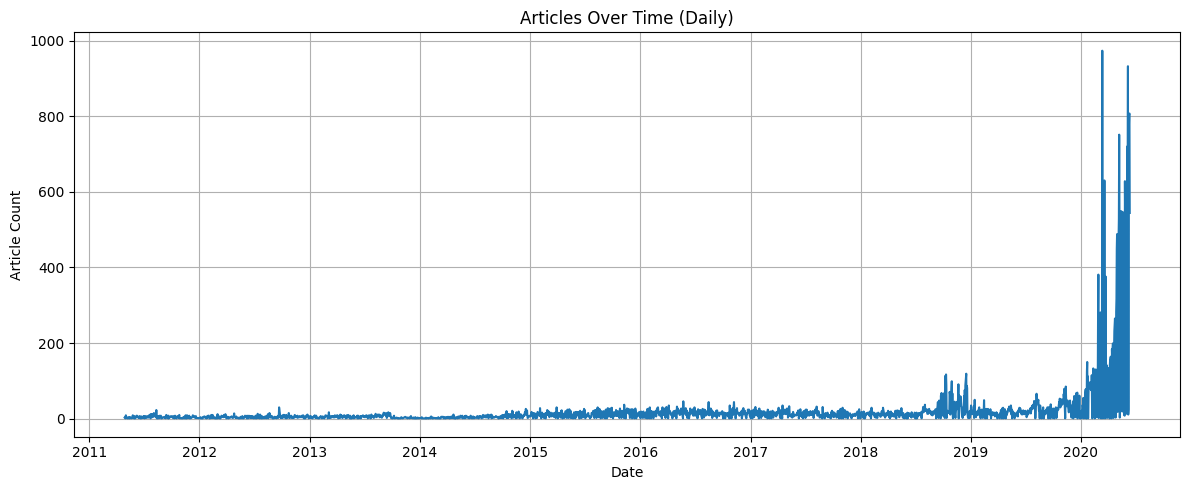

In [11]:
plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title('Articles Over Time (Daily)')
plt.xlabel('Date')
plt.ylabel('Article Count')
plt.grid(True)
plt.tight_layout()
plt.show()


Articles by Day of Week:
 weekday
Friday        9407
Monday       10297
Saturday       273
Sunday         388
Thursday     12712
Tuesday      11037
Wednesday    11873
Name: count, dtype: int64


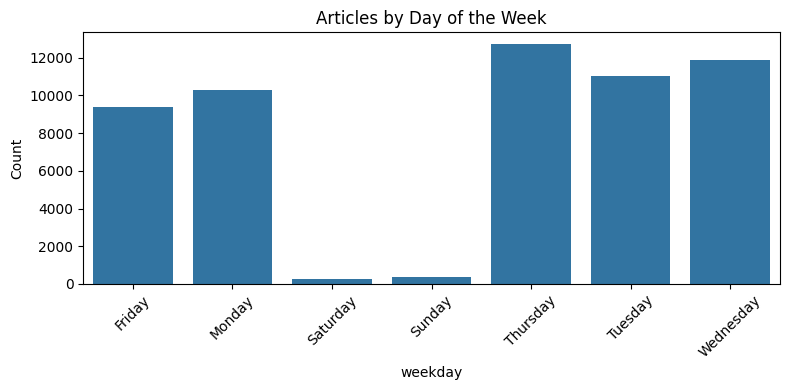

In [12]:
df['weekday'] = df['date'].dt.day_name()
weekday_counts = df['weekday'].value_counts().sort_index()

print("\nArticles by Day of Week:\n", weekday_counts)

# Bar plot for weekday distribution
plt.figure(figsize=(8, 4))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title('Articles by Day of the Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()